### 1. 머신러닝

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import koreanize_matplotlib
import seaborn as sns

warnings.filterwarnings('ignore')

#### 문제1. 신생아 건강 데이터 분석 (Newborn_Health.csv)
##### 데이터셋은 신생아(체중 1800g 이하, Low Birth Weight) 관련 정보를 포함하며, 연속형 변수 6~7개와 범주형(Yes/No) 변수 8~10개로 구성됩니다.

- 변수 예시:
- 연속형: 출생체중(g), 임신기간(주), 모체연령, 병원입원일수 등
- 범주형: 쌍둥이여부(Yes/No), 제왕절개여부(Yes/No), 신생아호흡곤란증후군(RDS, Yes/No), 생존여부(0: 사망, 1: 생존) 등
- 뇌손상 관련 변수: D, E, F (각각 None, Mild, Severe, NA)
- 종속변수: 생존여부 (survival, 0/1)


각 컬럼에 대한 설명:

Maternal Age (엄마 나이): 출산 당시 엄마의 나이를 의미합니다.

Gestational Age (임신 주수): 임신 기간을 주 단위로 나타냅니다. 예를 들어, 40주는 만삭을 의미합니다. (마지막 월경 첫날부터 현재까지의 기간을 주단위로 계산하여 태아의 성장과 발달단계를 파악하는 중요한 의학적 지표이다.)

Birth Weight (출생 시 체중): 신생아의 출생 당시 체중을 그램(g) 또는 킬로그램(kg) 단위로 나타냅니다.

APGAR Score 1min (아프가 점수 1분): 출생 후 1분에 측정한 아프가 점수입니다. 아프가 점수는 신생아의 건강 상태를 평가하는 지표로, 피부색, 심박수, 반사 반응, 근긴장도, 호흡 등 5가지 항목을 평가하여 총 0점에서 10점까지 매깁니다.

APGAR Score 5min (아프가 점수 5분): 출생 후 5분에 측정한 아프가 점수입니다. 일반적으로 1분 점수보다 5분 점수가 신생아의 장기적인 예후와 더 관련이 깊다고 알려져 있습니다.

Sex (성별): 신생아의 성별을 나타냅니다 (예: 남, 여 또는 M, F).

Presence of Congenital Abnormality (선천성 기형 유무): 신생아에게 선천성 기형이 있는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Mode of Delivery (분만 방식): 분만 방식을 나타냅니다 (예: 자연 분만, 제왕절개 등).

NICU Admission (신생아 중환자실 입원 여부): 신생아가 출생 후 신생아 중환자실(NICU)에 입원했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Respiratory Distress Syndrome (RDS) (호흡곤란 증후군 (RDS) 발생 여부): 신생아에게 호흡곤란 증후군이 발생했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

#### 데이터 특이사항:

- 결측값 비율: 약 10~15%
- BrainDamage 변수의 NA 비율: 약 20%
- Python/R로 분석 가능, sklearn/xgboost 패키지 사용 권장.

In [19]:
d1 = pd.read_csv('Newborn_Health.csv')
d1.head()

,id,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,oxygen_days,body_temp,twins,c_section,rds,d,e,f,infection,ventilation,gender,survival
0,1,1599.342831,34.798711,26.624109,9,7,1,36.134429,No,No,No,Severe,None,None,No,No,M,1
1,2,1472.347140,33.849267,29.277407,5,5,1,37.525633,No,Yes,Yes,Severe,NaN,Mild,No,No,F,0
2,3,1629.537708,32.119261,26.037900,12,8,2,37.248637,No,No,Yes,None,None,None,No,Yes,M,1
3,4,1800.000000,30.706126,28.460192,7,7,1,36.714612,No,Yes,No,None,None,Severe,No,No,F,1
4,5,1453.169325,33.396447,20.531927,7,6,4,36.208373,No,Yes,No,NaN,Severe,None,No,No,F,0


In [20]:
d1.isna().sum()

id                   0
birth_weight         0
gestational_age      0
maternal_age         0
hospital_days        0
apgar_score          0
oxygen_days          0
body_temp            0
twins                0
c_section            0
rds                  0
d                  203
e                  206
f                  200
infection            0
ventilation          0
gender               0
survival             0
dtype: int64

#### 1. 교차표 생성:
- 뇌손상 변수 D, E, F를 두 개씩 조합하여 교차표를 작성하고, 각 조합의 데이터 분포를 추정하시오. (예: D와 E의 교차표, E와 F의 교차표 등)

In [21]:
itter = [('d', 'e'), ('d', 'f'), ('e', 'f')]
odr = ['None', 'Mild', 'Severe', 'All']

for i1, i2 in itter:
    cr1 = pd.crosstab(d1[i1], d1[i2], margins=True)
    cr1 = cr1.reindex(index=odr, columns=odr)
    display(cr1)

e,None,Mild,Severe,All
d,,,,
None,242,94,48,384
Mild,102,33,21,156
Severe,49,25,10,84
All,393,152,79,624


f,None,Mild,Severe,All
d,,,,
None,216,123,49,388
Mild,89,43,24,156
Severe,52,31,8,91
All,357,197,81,635


f,None,Mild,Severe,All
e,,,,
None,234,114,55,403
Mild,89,48,16,153
Severe,43,25,13,81
All,366,187,84,637


In [22]:
for i1, i2 in itter:
    cr2 = pd.crosstab(d1[i1], d1[i2], margins=True, normalize=True)
    cr2 = cr2.reindex(index=odr, columns=odr)
    display(cr2)

e,None,Mild,Severe,All
d,,,,
None,0.387821,0.150641,0.076923,0.615385
Mild,0.163462,0.052885,0.033654,0.250000
Severe,0.078526,0.040064,0.016026,0.134615
All,0.629808,0.243590,0.126603,1.000000


f,None,Mild,Severe,All
d,,,,
None,0.340157,0.193701,0.077165,0.611024
Mild,0.140157,0.067717,0.037795,0.245669
Severe,0.081890,0.048819,0.012598,0.143307
All,0.562205,0.310236,0.127559,1.000000


f,None,Mild,Severe,All
e,,,,
None,0.367347,0.178964,0.086342,0.632653
Mild,0.139717,0.075353,0.025118,0.240188
Severe,0.067504,0.039246,0.020408,0.127159
All,0.574568,0.293564,0.131868,1.000000


모든 쌍에서 None의 비중이 가장 높으며, 중증의 비율이 가장 낮다.  

None->중증으로 갈수록 비율이 낮아지며, 단, f-e쌍의 경우 중증-중증 비율이 중증-중간 비율과 큰 차이를 보이지 않는다.

#### 2. 파생변수 생성:
- BrainDamage: D, E, F가 모두 NA이면 0, 하나라도 None/Mild/Severe이면 1, 그 외는 NA로 처리.
- SplitInd: BrainDamage가 0이면 0, NA이면 1, 그 외(1)는 2로 처리.

In [23]:
cols = ['d', 'e', 'f']

cond1 = d1[cols].isna().all(axis=1)
cond2 = d1[cols].isin(['None', 'Mild', 'Severe']).any(axis=1)

d1['damage'] = np.where(cond1, 0, np.where(cond2, 1, 0)).astype('O')
d1['sp'] = np.where(d1['damage'] == 0, 0, np.where(d1['damage'].isna(), 1, 2)).astype('O')

In [24]:
d1['damage'].value_counts()

1    994
0      6
Name: damage, dtype: int64

In [25]:
d1['sp'].value_counts()

2    994
0      6
Name: sp, dtype: int64

#### 3. 데이터 전처리:
- 결측값 처리: 연속형 변수는 중앙값으로, 범주형 변수는 최빈값으로 대체.
- 불필요한 변수(예: ID, 상수값 변수) 제거.

In [26]:
d1.isna().sum()[d1.isna().sum()>0]

d    203
e    206
f    200
dtype: int64

In [27]:
for col in ['d', 'e', 'f']:
    d1[col] = d1[col].fillna(d1[col].mode()[0])

#### 4. EDA (탐색적 데이터 분석):
- 생존여부(survival)와 BrainDamage에 따른 주요 변수(출생체중, 임신기간 등)의 분포를 시각화하고 상관관계 분석.

In [28]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1000 non-null   int64  
 1   birth_weight     1000 non-null   float64
 2   gestational_age  1000 non-null   float64
 3   maternal_age     1000 non-null   float64
 4   hospital_days    1000 non-null   int64  
 5   apgar_score      1000 non-null   int64  
 6   oxygen_days      1000 non-null   int64  
 7   body_temp        1000 non-null   float64
 8   twins            1000 non-null   object 
 9   c_section        1000 non-null   object 
 10  rds              1000 non-null   object 
 11  d                1000 non-null   object 
 12  e                1000 non-null   object 
 13  f                1000 non-null   object 
 14  infection        1000 non-null   object 
 15  ventilation      1000 non-null   object 
 16  gender           1000 non-null   object 
 17  survival       

In [29]:
d1.drop(columns='id', inplace=True)

<<연속형 변수 통계량 및 시각화>>


,count,mean,std,min,25%,50%,75%,max
birth_weight,1000.0,1497.507539,183.028100,851.746532,1370.481939,1505.060122,1629.588775,1800.000000
gestational_age,1000.0,32.141142,1.907676,28.000000,30.787517,32.126154,33.457764,36.000000
maternal_age,1000.0,30.035634,4.867969,18.000000,26.760002,29.998746,33.304577,45.000000
hospital_days,1000.0,9.975000,3.067864,5.000000,8.000000,10.000000,12.000000,21.000000
apgar_score,1000.0,6.416000,1.735499,4.000000,5.000000,6.000000,8.000000,9.000000
oxygen_days,1000.0,1.929000,1.337815,0.000000,1.000000,2.000000,3.000000,7.000000
body_temp,1000.0,36.806771,0.305139,36.000000,36.605420,36.808658,37.006225,37.813215


<<명목형 변수 통계량 및 시각화>>


,count,unique,top,freq
twins,1000,2,No,904
c_section,1000,2,No,587
rds,1000,2,No,675
d,1000,3,None,699
e,1000,3,None,707
f,1000,3,None,654
infection,1000,2,No,803
ventilation,1000,2,No,720
gender,1000,2,F,501


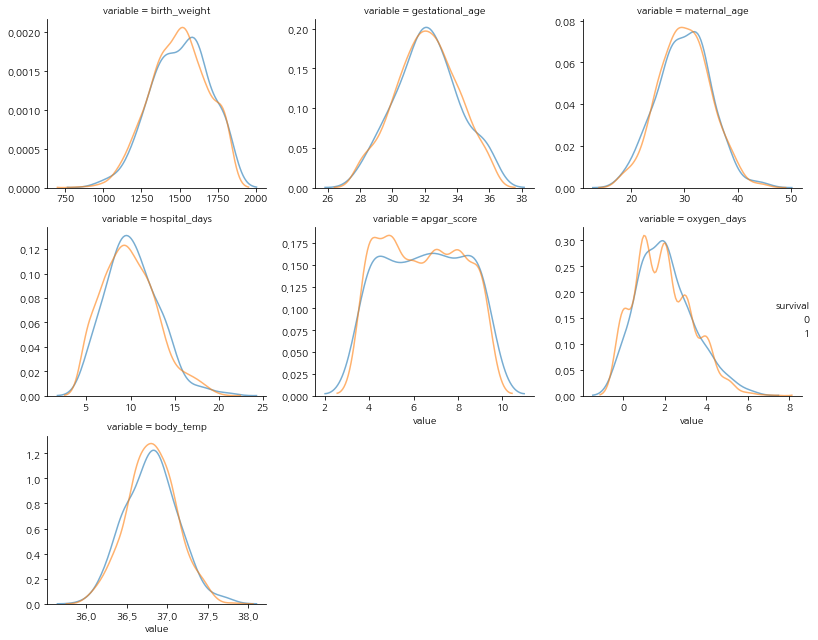

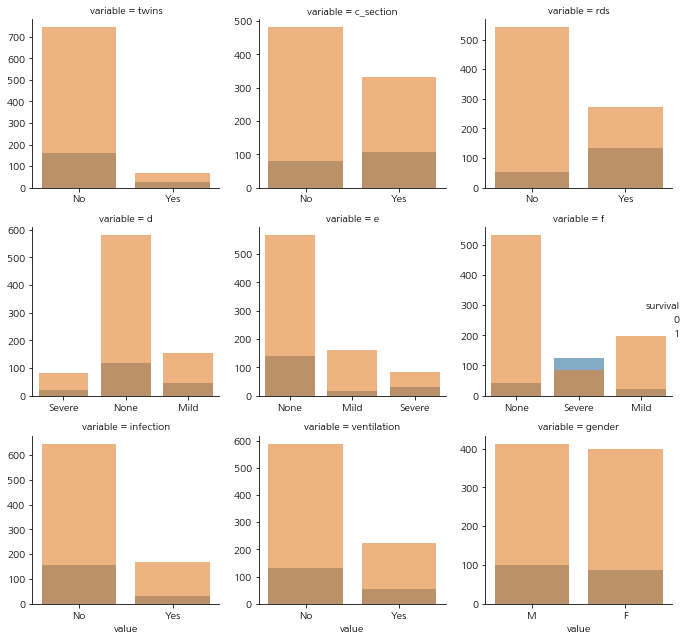

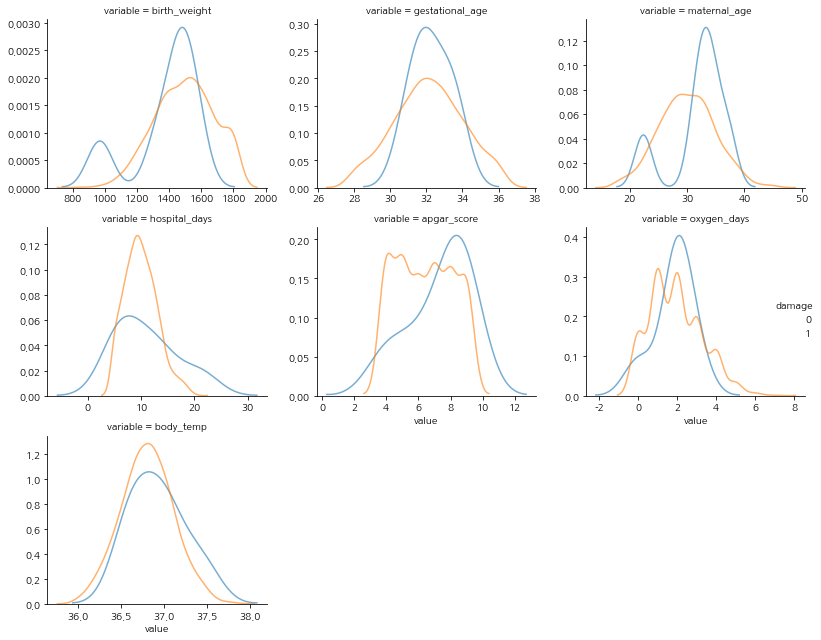

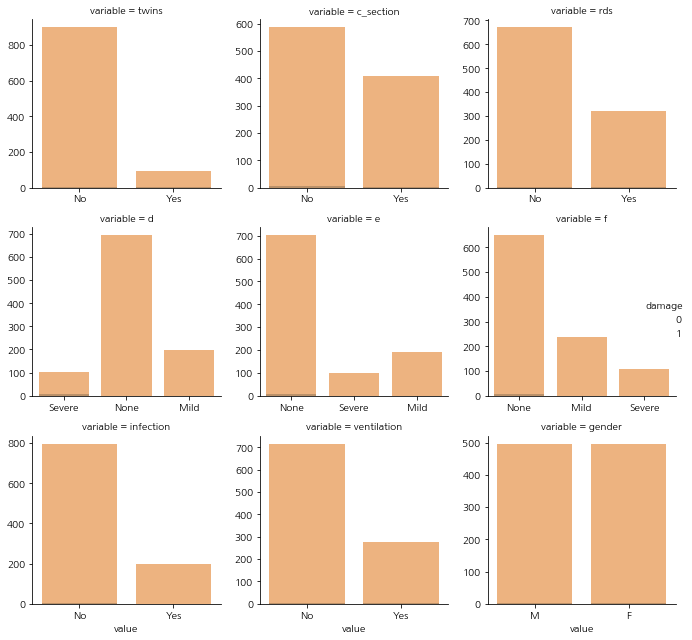

In [30]:
op = ['survival', 'damage']

n_cols = d1.select_dtypes('number').columns[:-1]
c_cols = d1.select_dtypes('O').columns[:-2]

print("<<연속형 변수 통계량 및 시각화>>")
display(d1[n_cols].describe().T)
print("<<명목형 변수 통계량 및 시각화>>")
display(d1[c_cols].describe().T)
for o in op:
    mt = d1.melt(id_vars=o, value_vars=n_cols)
    g = sns.FacetGrid(mt, col='variable', hue=o, col_wrap=3, sharex=False, sharey=False,  aspect=1.2)
    g.add_legend()
    g.map(sns.kdeplot, 'value', alpha=0.6)
    plt.tight_layout()
    plt.show()
    mt = d1.melt(id_vars=o, value_vars=c_cols)
    g = sns.FacetGrid(mt, col='variable', hue=o, col_wrap=3, sharex=False, sharey=False)
    g.add_legend()
    g.map(sns.countplot, 'value', alpha=0.6)
    plt.tight_layout()
    plt.show()



연속형 변수의 경우   
- 생존여부: 분포의 큰 차이를 보이지 않음(단 생존 시 아프간 점수가 4-6 사이로 낮은 비율이 높음)
- 뇌손상 여부: 분포의 차이를 보임(특징 있음)
   - 몸무게: 손상이 없을 경우 쌍봉분포, 있을 경우 다소 높은 경향
   - 임신주수는 정상인 경우 중앙(30-36)에 집중된 경향
   - 산모나이는 뇌손상이 없을 경우 쌍봉분포를 보임
등

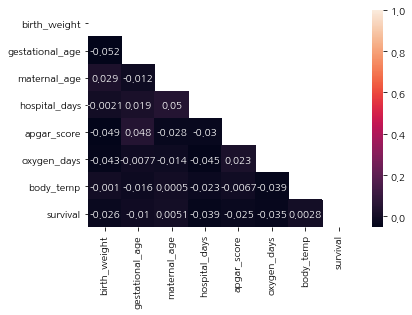

In [31]:
corr = d1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

선형 상관관계 상 각 설명변수 간 유의미한 선형상관관계 관찰되지 않음

#### 분류 분석:
- 단일 분류: 로지스틱 회귀 또는 의사결정나무를 사용하여 survival 예측.
- 앙상블 분류: 랜덤포레스트와 XGBoost를 사용하여 survival 예측.
- 모델 성능 비교(Accuracy, F1-Score, ROC-AUC).

불균형 데이터이므로 오버샘플링 고려

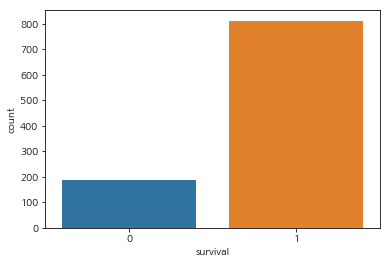

In [32]:
sns.countplot(d1['survival'])
plt.show()

In [33]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   birth_weight     1000 non-null   float64
 1   gestational_age  1000 non-null   float64
 2   maternal_age     1000 non-null   float64
 3   hospital_days    1000 non-null   int64  
 4   apgar_score      1000 non-null   int64  
 5   oxygen_days      1000 non-null   int64  
 6   body_temp        1000 non-null   float64
 7   twins            1000 non-null   object 
 8   c_section        1000 non-null   object 
 9   rds              1000 non-null   object 
 10  d                1000 non-null   object 
 11  e                1000 non-null   object 
 12  f                1000 non-null   object 
 13  infection        1000 non-null   object 
 14  ventilation      1000 non-null   object 
 15  gender           1000 non-null   object 
 16  survival         1000 non-null   int64  
 17  damage         

In [34]:
#단일분류

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

x = d1.drop(columns=['survival'])
y = d1['survival'].astype('int64')

train_x, test_x, train_y, test_y = train_test_split(x, y, stratify=y, random_state=42)

c_cols = train_x.select_dtypes('O').columns
n_cols = train_x.select_dtypes('number').columns

pre = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), n_cols), 
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols),
    remainder='passthrough'
)

pre2 = make_column_transformer(
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols),
    remainder='passthrough'
)

lg = Pipeline([
    ('pre_processor', pre), 
    ('smote', SMOTE(random_state=42)),
    ('cl', LogisticRegression(random_state=42))
])


rf = Pipeline([
    ('pre_processor', pre2), 
    ('smote', SMOTE(random_state=42)),
    ('cl', RandomForestClassifier(random_state=42))
])


m_list = [('로지스틱회귀', lg), ('랜덤포레스트분류', rf)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'acc', 'f1', 'auc'])

for n1, model in m_list:
    model.fit(train_x, train_y)
    for n2, x, y in d_list:
        pred = model.predict(x)
        acc = accuracy_score(y, pred)
        f1 = f1_score(y, pred, average='macro')
        auc = roc_auc_score(y, pred, average='macro')
        rs.loc[len(rs)] = [n1, n2, acc, f1, auc]
        print(classification_report(y, pred))
display(rs)

Using TensorFlow backend.


              precision    recall  f1-score   support

           0       0.21      0.51      0.29       140
           1       0.83      0.56      0.67       610

    accuracy                           0.55       750
   macro avg       0.52      0.53      0.48       750
weighted avg       0.71      0.55      0.60       750

              precision    recall  f1-score   support

           0       0.21      0.53      0.30        47
           1       0.83      0.53      0.65       203

    accuracy                           0.53       250
   macro avg       0.52      0.53      0.47       250
weighted avg       0.71      0.53      0.58       250

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       140
           1       1.00      1.00      1.00       610

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750

              preci

,model,data,acc,f1,auc
0,로지스틱회귀,train,0.546667,0.480309,0.531440
1,로지스틱회귀,test,0.532000,0.474025,0.531967
2,랜덤포레스트분류,train,1.000000,1.000000,1.000000
3,랜덤포레스트분류,test,0.800000,0.444444,0.492611


두 모델의 성능을 비교하면 정확도 측면에서는 랜덤포레스트 분류가,  f1, auc 측면에서는 로지스틱 회귀 모델이 높다.  

랜덤포레스트는 학습데이터는 완벽하게 학습하였으나, test set의 분류성능이 f1 0.44, auc 0.492로 매우 나쁜 성능을 보여주고 있다.  
낮은 비율의 레이블이었던 0레이블을 거의 예측하지 못하고 있다. (과적합)  

로지스틱 회귀는 과적합은 없으나 두 데이터셋에서 모두 낮은 성능을 보여주고 있다.  
acc/f1/auc 는 0.532000	/ 0.474025	 / 0.531967 이다.  
랜덤포레스트보다는 나은 성능이나, 레이블 0의 재현율(0.53)과 정밀도(0.21)가 아주 낮으며, 이 조화평균, auc score또한 아주 낮다.  

앞서 종속변수에 따른 데이터 분포에서 큰 차이를 보이지 않았으며, 종속변수의 레이블이 불균형을 보이는 바  
가능하다면 관찰데이터 증강 및 분류 특징이 뚜렷한 파생변수를 채택하는 것이 필요하다. 

### 2. 머신러닝

#### [문제 2] 재생에너지 발전량 예측 (Energy.csv, Climate.csv)
#### 두 데이터셋은 2021~2023년 3년간의 재생에너지 발전량과 기후 데이터를 포함합니다.

- Energy.csv:
- 변수: date(YYYYMMDD), source(태양광/풍력), generation(MWh), hour_0~hour_23(시간별 발전량)
총 발전량(generation)은 태양광과 풍력의 합.
- Climate.csv:
- 변수: date(YYYY-MM-DD), temperature(기온), humidity(습도), windspeed(풍속), precipitation(강수량)
- 일부 변수(temperature, precipitation)에 결측값 존재.

#### 데이터 특이사항:

- Energy.csv: 약 1000일 데이터, 결측값 5% 이하.
- Climate.csv: 약 1100일 데이터, 결측값 10% 내외.
- Python(Pandas, sklearn) 또는 R(dplyr, caret)로 분석 가능.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

energy_df = pd.read_csv('Energy.csv')
climate_df = pd.read_csv('Climate.csv')
energy_df.drop(columns=['generation'], inplace=True, axis=1)
display(energy_df.head())
display(climate_df.head())

,date,source,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,20210101,Solar,10.612776,18.919571,16.477538,8.827337,11.027004,7.320036,10.068342,4.565273,...,13.887643,11.554141,6.316949,1.052565,11.417600,15.073001,10.228990,13.390003,2.489640,9.963013
1,20210101,Wind,7.421830,5.520150,13.688934,19.836831,13.963826,9.462576,4.057822,16.606856,...,7.451766,8.677991,10.594264,13.060985,13.648189,4.026717,7.523877,19.683184,10.749592,0.637982
2,20210102,Solar,16.843117,7.082532,17.834894,5.903762,7.068822,7.476683,1.746394,4.873352,...,12.921522,11.551500,21.283893,6.781420,12.665406,12.035176,11.307375,17.278912,6.939721,2.568380
3,20210102,Wind,6.527484,4.081912,25.683430,15.869641,10.594932,23.009171,5.265074,3.742647,...,12.606121,6.423788,17.117713,7.361706,1.396033,12.943102,8.819983,10.153434,14.098082,14.236364
4,20210103,Solar,11.144246,13.060810,17.157265,17.923698,9.272692,12.561377,12.055105,9.167380,...,9.896769,8.531589,12.683250,11.809802,9.818225,2.075185,17.261561,12.466698,16.477671,15.787612


,date,temperature,humidity,windspeed,precipitation
0,2021-01-01,8.196357,60.767346,7.229558,0.133543
1,2021-01-02,7.842254,71.605808,1.878436,3.203037
2,2021-01-03,8.548918,46.904014,4.651294,2.122495
3,2021-01-04,25.446324,87.003296,0.126070,2.307601
4,2021-01-05,14.434452,52.582675,3.209874,0.562203


#### 2. 결측값 처리:
- temperature, precipitation은 결측값을 0으로 대체.
- 그 외 변수(humidity, windspeed 등)는 직전 값(Forward Fill)으로 대체.

In [36]:
climate_df[['temperature', 'precipitation']] = climate_df[['temperature', 'precipitation']].fillna(0)
climate_df = climate_df.fillna(method='ffill')
climate_df['date'] = pd.to_datetime(climate_df['date'], format='%Y-%m-%d')
climate_df.isna().sum()

date             0
temperature      0
humidity         0
windspeed        0
precipitation    0
dtype: int64

In [37]:
energy_df = energy_df.fillna(method='ffill')

In [38]:
mt = pd.melt(energy_df, id_vars=['date', 'source'], var_name='time', value_name= 'generation')
mt['time'] = mt['time'].str.replace('hour_', "").astype('int64')
mt['date'] = pd.to_datetime(mt['date'], format='%Y%m%d')

mt.head()

,date,source,time,generation
0,2021-01-01,Solar,0,10.612776
1,2021-01-01,Wind,0,7.421830
2,2021-01-02,Solar,0,16.843117
3,2021-01-02,Wind,0,6.527484
4,2021-01-03,Solar,0,11.144246


In [39]:
mg = pd.merge(mt, climate_df, how='left', on='date', sort='date')

mg.head()

,date,source,time,generation,temperature,humidity,windspeed,precipitation
0,2021-01-01,Solar,0,10.612776,8.196357,60.767346,7.229558,0.133543
1,2021-01-01,Wind,0,7.421830,8.196357,60.767346,7.229558,0.133543
2,2021-01-01,Solar,1,18.919571,8.196357,60.767346,7.229558,0.133543
3,2021-01-01,Wind,1,5.520150,8.196357,60.767346,7.229558,0.133543
4,2021-01-01,Solar,2,16.477538,8.196357,60.767346,7.229558,0.133543


In [40]:
mg.shape

(52560, 8)

#### 3. 파생변수 생성:
- Season: 월을 기준으로 계절 변수 생성 (3-5월: 봄, 6-8월: 여름, 9-11월: 가을, 12-2월: 겨울).

In [41]:
mg['month'] = mg['date'].dt.month 

cond1 = mg['month'].between(3, 5)
cond2 = mg['month'].between(6, 8)
cond3 = mg['month'].between(9, 11)

mg['season'] = np.where(cond1, '봄', np.where(cond2, '여름', np.where(cond3, ' 가을', '겨울')))

mg['season'].value_counts()

봄      13248
여름     13248
 가을    13104
겨울     12960
Name: season, dtype: int64

파생변수를 생성 후 빈도를 확인했을 때 대체로 비슷한 빈도를 보인다. 

#### 4. 탐색적 분석:
- 변수 간 상관관계 분석(예: generation과 temperature, windspeed 간 상관계수).
- 계절별 발전량 분포 시각화.

In [42]:
mg.drop(columns='month', inplace=True)

In [43]:
mg.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52560 entries, 0 to 52559
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           52560 non-null  datetime64[ns]
 1   source         52560 non-null  object        
 2   time           52560 non-null  int64         
 3   generation     52560 non-null  float64       
 4   temperature    52560 non-null  float64       
 5   humidity       52560 non-null  float64       
 6   windspeed      52560 non-null  float64       
 7   precipitation  52560 non-null  float64       
 8   season         52560 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 4.0+ MB


<<연속형 변수>>


,count,mean,std,min,25%,50%,75%,max
time,52560.0,11.500000,6.922252,0.0,5.750000,11.500000,17.250000,23.000000
generation,52560.0,10.046250,4.904408,0.0,6.582767,10.024193,13.399831,28.726896
temperature,52560.0,13.455020,10.018592,-10.0,6.027435,13.668884,20.710113,35.000000
humidity,52560.0,60.454380,14.880486,20.0,49.952177,60.199259,70.800384,100.000000
windspeed,52560.0,4.018379,1.972570,0.0,2.672366,3.969049,5.398664,9.603147
precipitation,52560.0,1.754513,1.955768,0.0,0.318567,1.173954,2.558745,15.608379


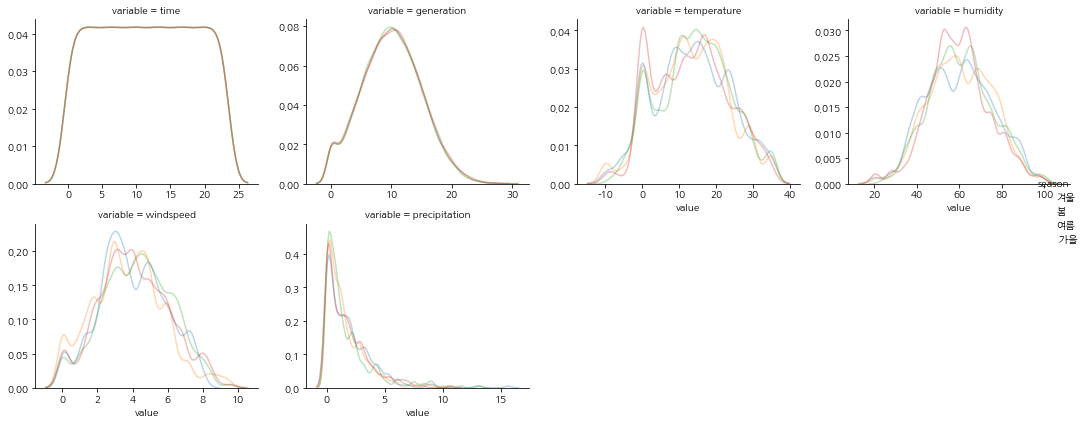

<<명목형 변수>>


,count,unique,top,freq
source,52560,2,Solar,26280


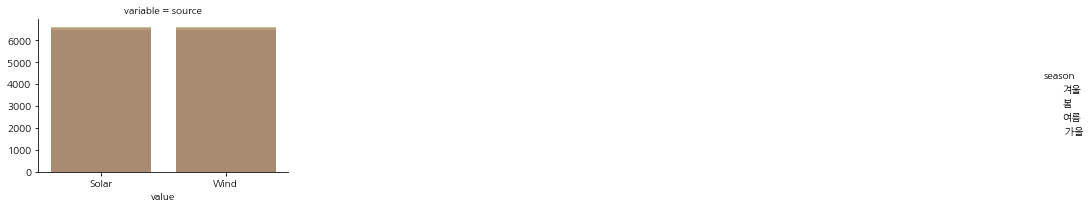

In [44]:
n_cols = mg.select_dtypes('number').columns
c_cols = mg.select_dtypes('O').columns[:-1]

print("<<연속형 변수>>")
display(mg[n_cols].describe().T)
mt = mg.melt(id_vars='season', value_vars=n_cols)
g = sns.FacetGrid(mt, col='variable', hue='season', aspect=1.2, height=3, col_wrap=4, sharex=False, sharey=False)
g.add_legend()
g.map(sns.kdeplot, 'value', alpha=0.3)
plt.show()

print("<<명목형 변수>>")
display(mg[c_cols].describe().T)
mt = mg.melt(id_vars='season', value_vars=c_cols)
g = sns.FacetGrid(mt, col='variable', hue='season',aspect=1.2, height=3, col_wrap=4, sharex=False, sharey=False)
g.add_legend()
g.map(sns.countplot, 'value', alpha=0.3)
plt.show()

각 계절별 분포는 비슷한 편이며, 발전량 또한 계절별로 큰 차이를 보이지 않는다.  

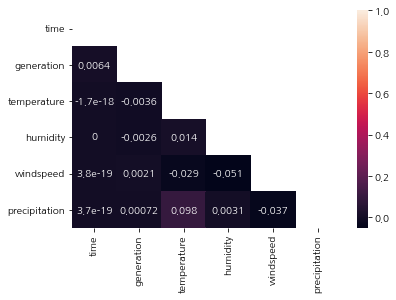

In [45]:
corr = mg.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

피어슨 선형상관관계 분석결과 발전량과 각 계절 변수들 간 유의미한 상관관계를 보이지 않는데  

이는 종속변수와 독립변수 간 유의미한 선형 특징이 없음을 알 수 있다. 

#### 5. 데이터 분할 및 예측:
- 2021~2022년 데이터를 학습(train), 2023년 데이터를 테스트(test)로 분할.
- 선형회귀, 랜덤포레스트를 사용하여 총 발전량(generation) 예측.
- 성능 평가: RMSE, R².

In [46]:
train, test = mg[mg['date'].dt.year.isin(['2021', '2022'])], mg[mg['date'].dt.year.isin(['2023'])]

train.shape, test.shape

((35040, 9), (17520, 9))

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import make_column_transformer

train_x, train_y = train.drop(columns=['date', 'generation']), train['generation']
test_x, test_y = test.drop(columns=['date', 'generation']), test['generation']

c_cols = ['time', 'season', 'source']
n_cols = ['temperature', 'humidity', 'windspeed', 'precipitation']

pre1 = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), n_cols), 
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)
pre2 = make_column_transformer(
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)


lr = Pipeline([
    ('pre', pre1), 
    ('lg', LinearRegression())
])
rf = Pipeline([
    ('pre', pre2), 
    ('lg', RandomForestRegressor(random_state=42))
])

m_list = [('다중선형회귀', lr), ('랜덤포레스트회귀', rf)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'r2', 'rmse'])

for n1, model in m_list:
    model.fit(train_x, train_y)
    for n2, x, y in d_list:
        pred = model.predict(x)
        r2 = r2_score(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rs.loc[len(rs)] = [n1, n2, r2, rmse]
display(rs)

,model,data,r2,rmse
0,다중선형회귀,train,0.001066,4.894848
1,다중선형회귀,test,-0.000795,4.919936
2,랜덤포레스트회귀,train,0.849265,1.901417
3,랜덤포레스트회귀,test,-0.044846,5.027049


In [48]:
4.919936/(test_y.max()-test_y.min())

0.18067366373621863

다중선형회귀의 성능이 뛰어나며, 일반화 성능을 보장한다.  
랜덤포레스트는 train set의 성능은 좋지만 과적합이 있기 때문에 적절하지 않다.  

다중선형회귀의 test set 기준으로 모델 성능을 해석하자면 모델의 분산설명력은 음수값으로 단순히 평균을 예측하는 모델보다   
성능이 낮으며, rmse 는4.919936로 상당히 낮은 성능을 보여주고 있다.(약 18%의 표준오차) 

이 낮은 성능은 앞서 종속변수와 설명변수의 상관관계가 거의 없었던 것과 연관이 있는데, 종속변수를 예측하기 위한  
적절한 패턴이 존재하지 않는다고 볼 수 있다.  
따라서 새로운 파생변수를 채택하거나, 데이터를 검토하는 것이 고려된다. 

### 3. 통계분석

#### [문제 3] 분산분석: 학습방법과 성별에 따른 성적 분석
#### 데이터셋은 학생 40명(남 20, 여 20)의 학습방법(3가지)별 성적을 포함합니다.
##### 변수:
- ID: 학생 식별자
- Gender: 성별 (M/F)
- LearningMethod: 학습방법 (Traditional, Online, Blended)
- Score: 성적 (0~100점)
##### 데이터 특이사항:
- 성적 분포: 평균 75, 표준편차 10 내외.
- Python(statsmodels) 또는 R(aov, TukeyHSD) 사용 권장.

In [49]:
d3 = pd.read_csv('./Learning_Score.csv')

In [50]:
d3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           40 non-null     int64 
 1   Gender       40 non-null     object
 2   Traditional  40 non-null     int64 
 3   Online       40 non-null     int64 
 4   Blended      40 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.7+ KB


In [51]:
d3.head()

,id,Gender,Traditional,Online,Blended
0,1,M,89,65,58
1,2,M,73,82,76
2,3,M,80,82,74
3,4,M,83,50,93
4,5,M,78,56,86


#### 1. 가정 검토:

해당 문제는 2 독립그룹이 3가지 학습방식을 동시에 수행하였으며, 종속변수인 점수는 연속형 변수이므로  
잔차의 기본가정을 만족한다면 혼합설계 분산분석을 수행할 수 있다. 

- between 요인: 독립요인으로 여기서는 성별
- within 요인: 반복측정 요인으로 여기서는 학습방식

잔차의 정규성, 등분산성(between 요인간), 구형성(within 요인), 독립성을 확인해야 하는데,   

- 정규성: 각 그룹내 잔차는 정규분포 따름
- 독립성: 독립요인 관찰값은 서로 독립(여기서는 실험데이터로 독립적으로 수집된 것으로 가정)
- 구형성: 반복측정 요인수준 간 공분산 행렬 동일
- 등분산성: 독립요인 그룹 간 분산 동일

잔차 검정이 정확하지만, 여기서는 데이터를 통해 사전 가정 만족 여부를 확인하는 것으로 한다.  

구형성은 greenhouse ee의 socre 가 0.75이상이면 만족하는 것으로 한다.(높을수록 구형성 가정 만족 높음)

In [52]:
mt = pd.melt(d3, id_vars=['id', 'Gender'], value_name='score', var_name='method')

In [53]:
from scipy.stats import shapiro, levene

gr = [(name, g['score']) for name, g in mt.groupby(['Gender', 'method'])]

#정규성 확인
for name, g in gr:
    stat, p = shapiro(g)
    print(f"1. {name} 그룹 정규성 만족여부: {p:.3f}", "만족" if p>= 0.05 else "불만족")

#등분산성 확인
gr = [(name, g['score']) for name, g in mt.groupby(['Gender'])]
stat, p = levene(gr[0][1], gr[1][1])
print(f"2. 그룹 등분산성 만족여부: {p:.3f}", "만족" if p>= 0.05 else "불만족")

1. ('F', 'Blended') 그룹 정규성 만족여부: 0.339 만족
1. ('F', 'Online') 그룹 정규성 만족여부: 0.094 만족
1. ('F', 'Traditional') 그룹 정규성 만족여부: 0.476 만족
1. ('M', 'Blended') 그룹 정규성 만족여부: 0.566 만족
1. ('M', 'Online') 그룹 정규성 만족여부: 0.115 만족
1. ('M', 'Traditional') 그룹 정규성 만족여부: 0.886 만족
2. 그룹 등분산성 만족여부: 0.638 만족


In [70]:
import pingouin as pg

mix = pg.mixed_anova(dv='score', between='Gender', within='method', subject='id', data=mt, correction=True)

display(mix)

,Source,SS,DF1,DF2,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,Gender,0.033333,1,38,0.033333,0.000260,9.872168e-01,NaN,0.000007,NaN,NaN,NaN,NaN
1,method,4539.216667,2,76,2269.608333,22.577354,2.013656e-08,1.676235e-08,0.372703,0.995929,True,0.995913,0.925132
2,Interaction,118.816667,2,76,59.408333,0.590976,5.563113e-01,NaN,0.015314,NaN,NaN,NaN,NaN


- 정규성: 모든 그룹(2*3=6)의 정규성을 만족한다.(귀무가설 기각)
- 등분산성: between 요인 그룹 간 등분산성 만족
- 독립성: 수집된 데이터로 독립성 만족
- 구형성: 만족(within 요인인 method의 GG eps 가 0.995929)  

따라서 분산분석을 수행할 수 있다.  다만 between 요인인 Gender의 pvalue 가 0.9872168로 귀무가설을 기각할 수 없으므로  
독립요인은 통계적으로 유의하지 않다.  따라서 within 요인만을 사용하여 일원배치 반복측정 anova를 수행한다. 

#### 2. 분산분석:

반복측정 요인인 method를 독립변수로 하는 일원배치 반복측정 anova를 유의수준 5% 하에서 수행한다. 

- 귀무가설: 학습방법에 따른 평균성적 차이는 없다. 
- 대립가설: 적어도 하나의 학습방법의 평균성적은 차이가 있다. 

In [71]:
model = pg.rm_anova(dv='score', within='method', subject='id', data=mt, correction=True)
display(model)

,Source,ddof1,ddof2,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,method,2,78,22.816651,1.579088e-08,1.676235e-08,0.369102,0.995929,True,0.995913,0.925132


pvalue가  1.579088e-08로 귀무가설을 기각한다. 따라서 적어도 하나의 학습방법의 평균성적은 차이가 있다.는 대립가설을 채택한다. 

#### 3. 사후분석:
- 유의미한 효과가 발견될 경우, Tukey HSD 테스트로 사후분석 수행.

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
Blended      Online  -14.525    0.0 -20.0399 -9.0101   True
Blended Traditional     -3.8 0.2348  -9.3149  1.7149  False
 Online Traditional   10.725    0.0   5.2101 16.2399   True
-----------------------------------------------------------


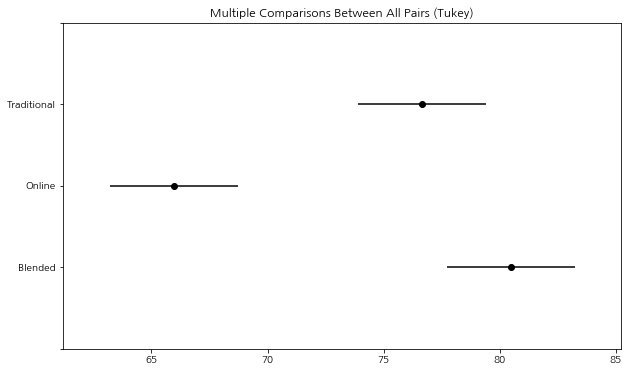

In [56]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=mt['score'], groups=mt['method'], alpha=0.05)
print(rs)

rs.plot_simultaneous()
plt.show()

#### 4. 결과 해석:
- 각 효과의 p-value와 통계적 유의성 논의.
- 학습방법별 평균 성적 비교 시각화.

Blended- Online, Online-Traditional 간에는 통계적으로 유의한 차이가 있으며(대립가설 채택)

Traditional- Blended(0.2348)간에는 통계적으로 유의한 차이가 존재하지 않는다.  

도표를 통해 더욱 확실하게 확인할 수 있다.  

평균을 기준으로 보면 온라인 학습의 평균성적이 가장 낮으며, 블랜디드 학습 평균성적이 가장 높다.  
블랜디드-전통적 학습의 평균 차가 유의하지는 않지만, 평균을 기준으로 블랜디드 학습이 가장 높으므로  
비용 등 외부요인을 따져서 둘 중 합리적인 방식을 채택할 수 있을 것이다. 

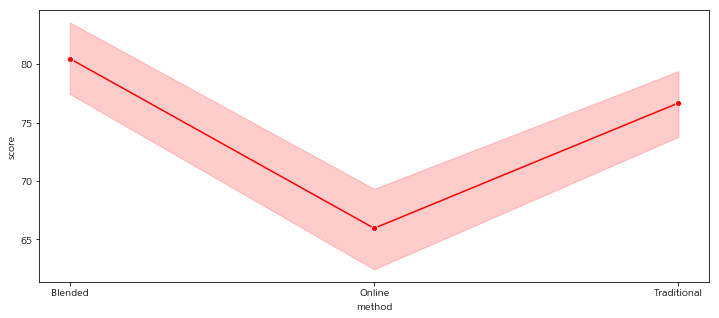

In [57]:
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(data=mt, x='method', y='score', marker='o', color='r')
plt.show()

### 4. 통계분석

#### [문제 4] 회귀분석: 학업 성취도 예측

#### 데이터셋은 학생 500명의 학업 관련 변수를 포함하며, 국어 성적을 예측하는 회귀분석을 수행합니다.

- 변수:
- ID: 학생 식별자
- StudyTime: 주간 공부시간 (0: 10시간 이하, 1: 1115시간, 2: 1620시간, 3: 21~25시간, 4: 26시간 이상)
- Tutoring: 과외 여부 (Yes/No)
- OnlineCourse: 온라인 강의 수강 여부 (Yes/No)
- Absences: 결석 일수 (평균 4, Q3: 8, 최대 25)
- Failures: 낙제 횟수 (0~3)
- Score: 국어 성적 (0~20점)
#### 데이터 특이사항:
- 결측값: 약 5% (Absences, Failures 중심).
- 범주형 변수(Tutoring, OnlineCourse)는 더미 변수로 변환 필요.
- Python(sklearn, statsmodels) 또는 R(lm, randomForest) 사용 권장.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

d4 = pd.read_csv('Academic_Performance.csv')
d4.head()

,id,StudyTime,Tutoring,OnlineCourse,Absences,Failures,Score
0,1,3,Yes,Yes,8.0,0.0,12
1,2,1,Yes,Yes,4.0,2.0,11
2,3,1,Yes,No,7.0,1.0,14
3,4,2,No,No,7.0,1.0,14
4,5,0,No,Yes,5.0,1.0,11


In [59]:
d4.isna().sum()

id               0
StudyTime        0
Tutoring         0
OnlineCourse     0
Absences        25
Failures        25
Score            0
dtype: int64

In [60]:
d4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            500 non-null    int64  
 1   StudyTime     500 non-null    int64  
 2   Tutoring      500 non-null    object 
 3   OnlineCourse  500 non-null    object 
 4   Absences      475 non-null    float64
 5   Failures      475 non-null    float64
 6   Score         500 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB


In [61]:
d4 = d4.dropna()

#### 가정 검토:

다중회귀분석은 다음과 같은 5가지 잔차의 기본가정을 만족해야만 모델 학습 결과를 신뢰할 수 있다.  

- 정규성: 잔차가 정규분포를 따름(shapiro 검정, qq-plot)
- 선형성: 독립변수와 종속변수 간 선형관계(잔차와 예측값의 산점도)
- 등분산성: 모든 값에서 잔차분산이 동일(브로슈 파간 검정)
- 독립성: 잔차들이 자기상관이 없다.(더빈왓슨 검정)
- 다중공선성 없음: vif 10이상 값이 있는지 확인

In [62]:
d4.drop(columns='id', inplace=True)

In [63]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

x = d4.drop(columns='Score')
y = d4['Score']

c_cols = x.select_dtypes('O').columns
n_cols = x.select_dtypes('number').columns

x = pd.get_dummies(x, columns=c_cols, drop_first=True)

sc = StandardScaler()

x[n_cols] = sc.fit_transform(x[n_cols])

x = sm.add_constant(x)

lr1 = sm.OLS(y, x).fit()

print(lr1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.206
Date:                Thu, 09 Oct 2025   Prob (F-statistic):             0.0526
Time:                        17:57:26   Log-Likelihood:                -1179.1
No. Observations:                 475   AIC:                             2370.
Df Residuals:                     469   BIC:                             2395.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               14.4586      0.261  

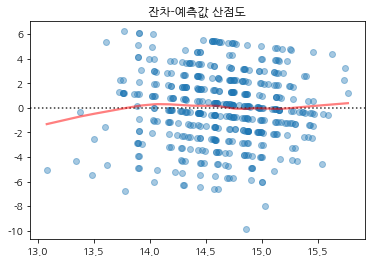

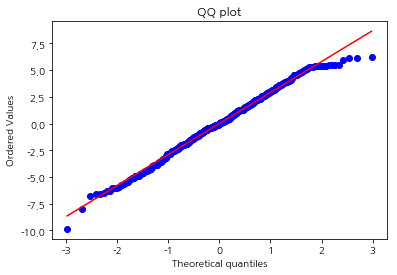

정규성 검정결과(0.019): 불만족
등분산성 검정결과(0.049): 불만족
독립성 검정결과: 만족


,name,vif
0,const,3.815782
1,StudyTime,1.032950
2,Absences,1.015817
3,Failures,1.015863
4,Tutoring_Yes,1.009060
5,OnlineCourse_Yes,1.016488


In [64]:
from scipy.stats import shapiro, probplot
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

fitted = lr1.fittedvalues
resid = lr1.resid

sns.residplot(x=fitted, y=resid, lowess=True, scatter_kws={'alpha': 0.4}, line_kws={'alpha':0.5, 'color': 'r'})
plt.title('잔차-예측값 산점도')
plt.show()

probplot(resid, dist='norm', fit=True, plot=plt)
plt.title(f"QQ plot")
plt.show()

stat, p = shapiro(resid)
print(f"정규성 검정결과({p:.3f}):", "만족" if p >= 0.05 else "불만족")

stat, p, _, _ = het_breuschpagan(resid, lr1.model.exog)
print(f"등분산성 검정결과({p:.3f}):", "만족" if p >= 0.05 else "불만족")

dw = durbin_watson(resid)
print(f"독립성 검정결과:", "만족" if (dw >= 1.5) & (dw <= 2.5) else "불만족")


vif = pd.DataFrame()
vif['name'] = lr1.model.exog_names
vif['vif'] = [variance_inflation_factor(lr1.model.exog, i) for i in range(len(lr1.model.exog_names))]
display(vif)

회귀 기본가정 중 독립성, 다중공선성 없음만을 만족하며,   

정규성, 등분산성 가정을 만족하지 않는다.  


따라서 다중회귀모델은 해당 데이터에 적절하지 않다.

#### 회귀분석:
선형회귀분석 수행(종속변수: Score, 독립변수: StudyTime, Tutoring, OnlineCourse, Absences, Failures).
기계학습 모델(예: 랜덤포레스트)과 비교.

In [65]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split


x = d4.drop(columns='Score')
y = d4['Score']

c_cols = x.select_dtypes('O').columns
n_cols = x.select_dtypes('number').columns

x = pd.get_dummies(x, columns=c_cols, drop_first=True)

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42)

lr = sm.OLS(train_y, sm.add_constant(train_x)).fit()
rf = RandomForestRegressor(random_state=42)
rf.fit(train_x, train_y)

m_list = [('다중선형회귀', lr), ('랜덤포레스트 회귀', rf)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]
rs = pd.DataFrame(columns=['model', 'data', 'r2', 'rmse'])

for n1, model in m_list:
    for n2, x, y, in d_list:
        if n1 == '다중선형회귀':
            x = sm.add_constant(x)
            proba = model.predict(x)
            pred = np.where(proba>=0.5, 1, 0)
        else:
            pred = model.predict(x)
        r2 = r2_score(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rs.loc[len(rs)] = [n1, n2, r2, rmse]
display(rs)



,model,data,r2,rmse
0,다중선형회귀,train,-20.244275,13.875449
1,다중선형회귀,test,-27.522544,14.175076
2,랜덤포레스트 회귀,train,0.547804,2.024368
3,랜덤포레스트 회귀,test,-0.431900,3.176051


두 모델 학습결과 랜덤포레스트 모델의 성능이 확연히 뛰어났다.  
이는 다중선형회귀의 기본가정을 만족하지 않아 모델의 성능이 낮으며, 회귀계수 또한 신뢰할 수 없음을 뜻한다.  

#### 다중공선성:
VIF(Variance Inflation Factor) 계산 및 다중공선성 평가.

In [66]:
vif = pd.DataFrame()
vif['name'] = lr.model.exog_names
vif['vif'] = [variance_inflation_factor(lr.model.exog, i) for i in range(len(lr.model.exog_names))]
display(vif[1:])

,name,vif
1,StudyTime,1.039979
2,Absences,1.015072
3,Failures,1.016726
4,Tutoring_Yes,1.015351
5,OnlineCourse_Yes,1.015902


vif 결과 vif 10이상의 변수가 없으므로 다중공선성은 존재하지 않는다. 

#### 변수 중요도:
회귀계수의 p-value를 통해 통계적 유의성 확인.
랜덤포레스트의 feature importance 분석.

In [67]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     2.015
Date:                Thu, 09 Oct 2025   Prob (F-statistic):             0.0760
Time:                        17:57:27   Log-Likelihood:                -892.43
No. Observations:                 356   AIC:                             1797.
Df Residuals:                     350   BIC:                             1820.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               14.6292      0.498  

다중회귀모형의 F 통계량 pvalue가 0.0760로 유의수준 5% 하에서 귀무가설을 기각할 수 없다.  
따라서 회귀계수가 통계적으로 유의하지 않다. 

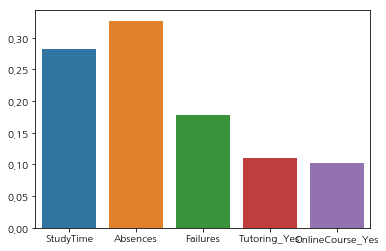

In [68]:
value = rf.feature_importances_
cols = train_x.columns

sns.barplot(x=cols, y=value)
plt.show()

랜덤포레스트 학습 간 변수중요도이다. Absences가 가장 높으며, 학습 방식이 가장 낮다.

#### 모델 평가:
R²: 모델이 성적의 변동을 얼마나 설명하는지 해석.
RMSE: 예측 오차 평가.

In [69]:
3.176051/ (test_y.max()- test_y.min())

0.2646709166666667

베스트 모델인 랜덤포레스트 기준 모델 평가이다.  
다소 과적합이 있다고 할 수 있으며, test set의 r2_score(-0.431900)가 음수로 단순하게 평균을 예측하는 모델보다 변동 설명력이 낮다.  
또한 rmse가 3.176051 로 전체 데이터 범위인 12 대비 표준오차가 26.5%로 매우 오차가 높다.


In [83]:
from scipy.stats import pearsonr
cols = mg.columns[4:8]

for c in cols:
    r, p = pearsonr(mg['generation'], mg[c])

    print(f"- {c} 변수 피어슨 상관관계 분석결과: {r:.3f} / pvalue {p:.3f}")

- temperature 변수 피어슨 상관관계 분석결과: -0.004 / pvalue 0.414
- humidity 변수 피어슨 상관관계 분석결과: -0.003 / pvalue 0.553
- windspeed 변수 피어슨 상관관계 분석결과: 0.002 / pvalue 0.632
- precipitation 변수 피어슨 상관관계 분석결과: 0.001 / pvalue 0.869


In [87]:
from scipy.stats import t

x, n, s = 6.2, 20, 1.5
a = 0.05
df = n-1

t.interval(1-a, df, x, s/np.sqrt(n))

(5.497978390370136, 6.902021609629864)

In [ ]:
ci = stats.t.interval(alpha=0.95, df=df, loc=mean, scale=std/np.sqrt(n))